In [1]:
# classify_cnn.py
# fine-tunes a pretrained resnet18 on yoga-82 images
# tests at 6, 20, and 82 class levels

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"using device: {device}")


using device: cuda


In [22]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

DRIVE_BASE = "/content/drive/MyDrive/yoga_phase3"
TRAIN_CSV = f"{DRIVE_BASE}/train_outputs/filtered_rows.csv"
TEST_CSV = f"{DRIVE_BASE}/test_outputs/filtered_rows.csv"
OUTPUT_DIR = f"{DRIVE_BASE}/results/phase3/resnet50/6col"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# unzip to local colab storage (much faster than reading from drive)
if not os.path.exists("/content/images"):
    print("unzipping...")
    with zipfile.ZipFile(f"{DRIVE_BASE}/images.zip", "r") as z:
        z.extractall("/content")
    print("done!")

TRAIN_IMG_DIR = "/content/images"
TEST_IMG_DIR = "/content/images/test"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%ls

phase3/


In [4]:
import os
print(os.path.exists("/content/images"))
print(len(os.listdir("/content/images")))

True
84


In [5]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [6]:
# classify_cnn.py
# fine-tunes a pretrained resnet50 on yoga-82 images
# tests at 6, 20, and 82 class levels

# paths
TRAIN_IMG_DIR = "/content/images"   # unzipped here
TEST_IMG_DIR = "/content/images/test"  # test is inside images/test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

using device: cuda


In [23]:

class YogaDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# pretrained Resnet-50 model
def build_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    # freeze everything except layer4 and the new classifier
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.fc.in_features, num_classes))
    return model.to(device)

# 1 full pass throguh the training data
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            all_preds.extend(outputs.max(1)[1].cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

def train_model(model, train_loader, test_loader, num_epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
    )

    best_acc, best_state = 0, None
    history = {"train_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        preds, labels = evaluate(model, test_loader)
        test_acc = accuracy_score(labels, preds)
        print(f"epoch {epoch+1}/{num_epochs} loss={train_loss:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        if test_acc > best_acc:
            best_acc = test_acc
            best_state = model.state_dict().copy()

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def save_confusion_matrix(y_test, y_pred, label_names, title, path):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    n = len(label_names)
    fig, ax = plt.subplots(figsize=(max(6, n * 0.4), max(6, n * 0.4)))
    sns.heatmap(cm_norm, annot=(n <= 20), fmt=".2f" if n <= 20 else "",
                xticklabels=label_names, yticklabels=label_names,
                cmap="Blues", ax=ax, vmin=0, vmax=1)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right", fontsize=max(5, 10 - n // 10))
    plt.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)


def fix_paths(df, img_dir):
    # replace the original full_path with the new colab path
    df["full_path"] = df["rel_path"].apply(lambda x: os.path.join(img_dir, x))
    return df

In [8]:
# 82 class

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df = fix_paths(train_df, TRAIN_IMG_DIR)
test_df = fix_paths(test_df, TEST_IMG_DIR)

print(f"train: {len(train_df)} images, test: {len(test_df)} images")

# use only the 82-class labels
col = "label_82"

class_names = sorted(train_df[col].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

train_labels = train_df[col].map(class_to_idx).values
test_labels = test_df[col].map(class_to_idx).values

train_paths = train_df["full_path"].values
test_paths = test_df["full_path"].values

print(f"train: {len(train_paths)}, test: {len(test_paths)}, classes: {len(class_names)}")

train_loader = DataLoader(
    YogaDataset(train_paths, train_labels, train_transform),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    YogaDataset(test_paths, test_labels, test_transform),
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

model = build_model(len(class_names))

t0 = time()
model, history = train_model(model, train_loader, test_loader)
total_time = time() - t0

preds, true_labels = evaluate(model, test_loader)

acc = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds, average="weighted")

print(f"final: acc={acc:.4f} f1={f1:.4f} time={total_time:.0f}s")

train: 10976 images, test: 4195 images
train: 10976, test: 4195, classes: 82
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 1/15 loss=1.8037 train_acc=0.5297 test_acc=0.7342


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 2/15 loss=0.6159 train_acc=0.8228 test_acc=0.8105


...

epoch 14/15 loss=0.0286 train_acc=0.9921 test_acc=0.8534


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 15/15 loss=0.0324 train_acc=0.9913 test_acc=0.8148


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


final: acc=0.8148 f1=0.8145 time=2861s


In [9]:
print(history["train_loss"])
print(history["train_acc"])
print(history["test_acc"])

[1.803697662867888, 0.6159142178019004, 0.31857160719942423, 0.18297238670745675, 0.13609640220446245, 0.09328407721061792, 0.0787073091044479, 0.07742770964214606, 0.059975789422739526, 0.04502083507584375, 0.04881071531602097, 0.05466712857073895, 0.054992522380474966, 0.028574835153536888, 0.03240346637475216]
[0.529701166180758, 0.8227951895043731, 0.9026056851311953, 0.9444241982507289, 0.9601858600583091, 0.9743075801749271, 0.9765852769679301, 0.9773141399416909, 0.9841472303206997, 0.9874271137026239, 0.9849672011661808, 0.9834183673469388, 0.985149416909621, 0.9920736151603499, 0.9912536443148688]
[0.734207389749702, 0.8104886769964244, 0.8212157330154947, 0.8162097735399285, 0.8350417163289631, 0.833611442193087, 0.833134684147795, 0.8195470798569726, 0.8443384982121573, 0.8488676996424315, 0.8402860548271752, 0.8398092967818832, 0.8450536352800954, 0.8533969010727056, 0.8147794994040525]


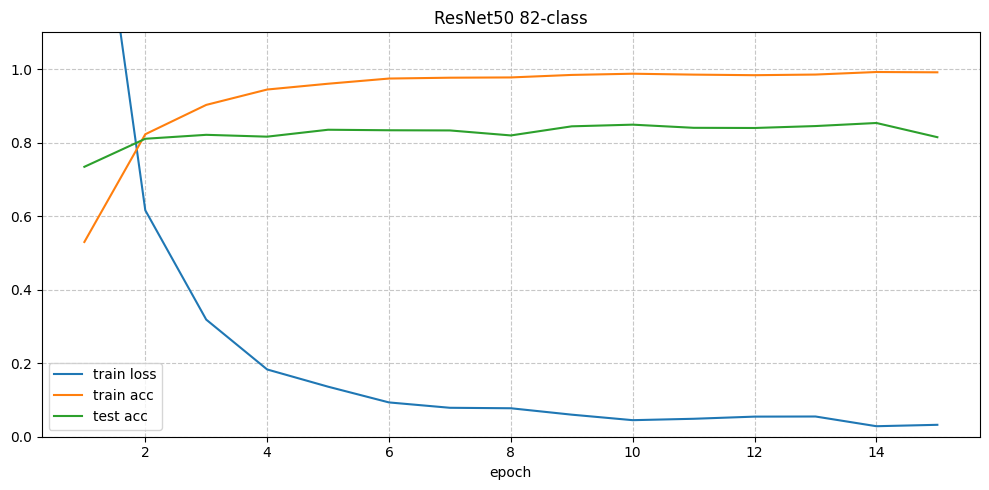

In [12]:
# train_loss
# [1.803697662867888, 0.6159142178019004, 0.31857160719942423, 0.18297238670745675, 0.13609640220446245, 0.09328407721061792, 0.0787073091044479, 0.07742770964214606, 0.059975789422739526, 0.04502083507584375, 0.04881071531602097, 0.05466712857073895, 0.054992522380474966, 0.028574835153536888, 0.03240346637475216]
# train_acc
# [0.529701166180758, 0.8227951895043731, 0.9026056851311953, 0.9444241982507289, 0.9601858600583091, 0.9743075801749271, 0.9765852769679301, 0.9773141399416909, 0.9841472303206997, 0.9874271137026239, 0.9849672011661808, 0.9834183673469388, 0.985149416909621, 0.9920736151603499, 0.9912536443148688]
# test_acc
# [0.734207389749702, 0.8104886769964244, 0.8212157330154947, 0.8162097735399285, 0.8350417163289631, 0.833611442193087, 0.833134684147795, 0.8195470798569726, 0.8443384982121573, 0.8488676996424315, 0.8402860548271752, 0.8398092967818832, 0.8450536352800954, 0.8533969010727056, 0.8147794994040525]


epochs = range(1, len(history["train_acc"]) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("epoch")
plt.title("ResNet50 82-class")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet50_82class_curve.png"), dpi=150)
plt.show()

In [13]:
save_confusion_matrix(
    true_labels,
    preds,
    class_names,
    "ResNet50 82-class",
    os.path.join(OUTPUT_DIR, "cm_resnet_82_class_exp1.png")
)

In [16]:
# 20 class

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df = fix_paths(train_df, TRAIN_IMG_DIR)
test_df = fix_paths(test_df, TEST_IMG_DIR)

print(f"train: {len(train_df)} images, test: {len(test_df)} images")

# use only the 20-class labels
col = "label_20"

class_names = sorted(train_df[col].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

train_labels = train_df[col].map(class_to_idx).values
test_labels = test_df[col].map(class_to_idx).values

train_paths = train_df["full_path"].values
test_paths = test_df["full_path"].values

print(f"train: {len(train_paths)}, test: {len(test_paths)}, classes: {len(class_names)}")

train_loader = DataLoader(
    YogaDataset(train_paths, train_labels, train_transform),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    YogaDataset(test_paths, test_labels, test_transform),
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

model = build_model(len(class_names))

t0 = time()
model, history = train_model(model, train_loader, test_loader)
total_time = time() - t0

preds, true_labels = evaluate(model, test_loader)

acc = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds, average="weighted")

print(f"final: acc={acc:.4f} f1={f1:.4f} time={total_time:.0f}s")

train: 10976 images, test: 4195 images
train: 10976, test: 4195, classes: 20


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 1/15 loss=1.0638 train_acc=0.6708 test_acc=0.8267


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 2/15 loss=0.3931 train_acc=0.8755 test_acc=0.8663


...

epoch 14/15 loss=0.0294 train_acc=0.9903 test_acc=0.8720


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 15/15 loss=0.0345 train_acc=0.9902 test_acc=0.8989


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


final: acc=0.8989 f1=0.8987 time=2741s


In [17]:
print(history["train_loss"])
print(history["train_acc"])
print(history["test_acc"])

[1.0638385383797804, 0.39313055044881806, 0.21213627275372735, 0.1348634637327479, 0.10525175740089777, 0.08242723109667616, 0.062270964496855895, 0.05598247374316987, 0.05192466736628617, 0.05032125672049897, 0.041640133266717345, 0.044524368163097766, 0.03262334486483881, 0.02940321339561764, 0.034491105935364585]
[0.6708272594752187, 0.8755466472303207, 0.9311224489795918, 0.9568148688046647, 0.9655612244897959, 0.9723943148688047, 0.9811406705539358, 0.9819606413994169, 0.983509475218659, 0.9845116618075802, 0.9856960641399417, 0.9870626822157434, 0.9902514577259475, 0.9902514577259475, 0.9901603498542274]
[0.8266984505363528, 0.86626936829559, 0.8638855780691299, 0.86507747318236, 0.8457687723480334, 0.8500595947556615, 0.8891537544696066, 0.8741358760429082, 0.8831942789034565, 0.8831942789034565, 0.8915375446960667, 0.8862932061978546, 0.8915375446960667, 0.8719904648390941, 0.8989272943980929]


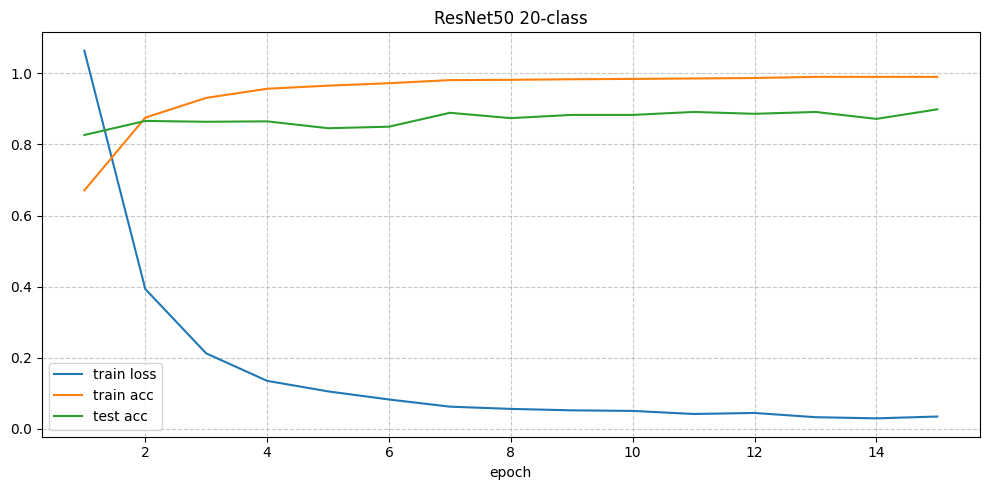

In [19]:
# train_loss
# [1.0638385383797804, 0.39313055044881806, 0.21213627275372735, 0.1348634637327479, 0.10525175740089777, 0.08242723109667616, 0.062270964496855895, 0.05598247374316987, 0.05192466736628617, 0.05032125672049897, 0.041640133266717345, 0.044524368163097766, 0.03262334486483881, 0.02940321339561764, 0.034491105935364585]
# train_acc
# [0.6708272594752187, 0.8755466472303207, 0.9311224489795918, 0.9568148688046647, 0.9655612244897959, 0.9723943148688047, 0.9811406705539358, 0.9819606413994169, 0.983509475218659, 0.9845116618075802, 0.9856960641399417, 0.9870626822157434, 0.9902514577259475, 0.9902514577259475, 0.9901603498542274]
# test_acc
# [0.8266984505363528, 0.86626936829559, 0.8638855780691299, 0.86507747318236, 0.8457687723480334, 0.8500595947556615, 0.8891537544696066, 0.8741358760429082, 0.8831942789034565, 0.8831942789034565, 0.8915375446960667, 0.8862932061978546, 0.8915375446960667, 0.8719904648390941, 0.8989272943980929]

epochs = range(1, len(history["train_acc"]) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("epoch")
plt.title("ResNet50 20-class")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet50_20class_curve.png"), dpi=150)
plt.show()

In [20]:
save_confusion_matrix(
    true_labels,
    preds,
    class_names,
    "ResNet50 20-class",
    os.path.join(OUTPUT_DIR, "cm_resnet50_20_class_exp1.png")
)

In [24]:
# 6 class

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df = fix_paths(train_df, TRAIN_IMG_DIR)
test_df = fix_paths(test_df, TEST_IMG_DIR)

print(f"train: {len(train_df)} images, test: {len(test_df)} images")

# use only the 6-class labels
col = "label_6"

class_names = sorted(train_df[col].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

train_labels = train_df[col].map(class_to_idx).values
test_labels = test_df[col].map(class_to_idx).values

train_paths = train_df["full_path"].values
test_paths = test_df["full_path"].values

print(f"train: {len(train_paths)}, test: {len(test_paths)}, classes: {len(class_names)}")

train_loader = DataLoader(
    YogaDataset(train_paths, train_labels, train_transform),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    YogaDataset(test_paths, test_labels, test_transform),
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

model = build_model(len(class_names))

t0 = time()
model, history = train_model(model, train_loader, test_loader)
total_time = time() - t0

preds, true_labels = evaluate(model, test_loader)

acc = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds, average="weighted")

print(f"final: acc={acc:.4f} f1={f1:.4f} time={total_time:.0f}s")

train: 10976 images, test: 4195 images
train: 10976, test: 4195, classes: 6


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 1/15 loss=0.5974 train_acc=0.7978 test_acc=0.8405


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 2/15 loss=0.2448 train_acc=0.9201 test_acc=0.8701


...

epoch 14/15 loss=0.0298 train_acc=0.9907 test_acc=0.9304


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch 15/15 loss=0.0220 train_acc=0.9930 test_acc=0.9240


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


final: acc=0.9240 f1=0.9238 time=2761s


In [26]:
print(history["train_loss"])
print(history["train_acc"])
print(history["test_acc"])

[0.5974006920227504, 0.24477527916170766, 0.14259084045300505, 0.09348892681802957, 0.07616638575895057, 0.054889986356353775, 0.044880735768180385, 0.040312274307662176, 0.03488141410458363, 0.03623553882541376, 0.03247416968146083, 0.027689423003018788, 0.02111845410749847, 0.029805854058122083, 0.02196057397431961]
[0.7978316326530612, 0.9200983965014577, 0.9532616618075802, 0.9691144314868805, 0.9759475218658892, 0.982051749271137, 0.9854227405247813, 0.9863338192419825, 0.9883381924198251, 0.986698250728863, 0.9887937317784257, 0.9909803206997084, 0.9937135568513119, 0.9907069970845481, 0.9929846938775511]
[0.8405244338498212, 0.8700834326579261, 0.9165673420738975, 0.9077473182359952, 0.9220500595947556, 0.9168057210965435, 0.9163289630512514, 0.9261025029797377, 0.9244338498212157, 0.930393325387366, 0.9096543504171632, 0.9210965435041716, 0.9244338498212157, 0.930393325387366, 0.9239570917759237]


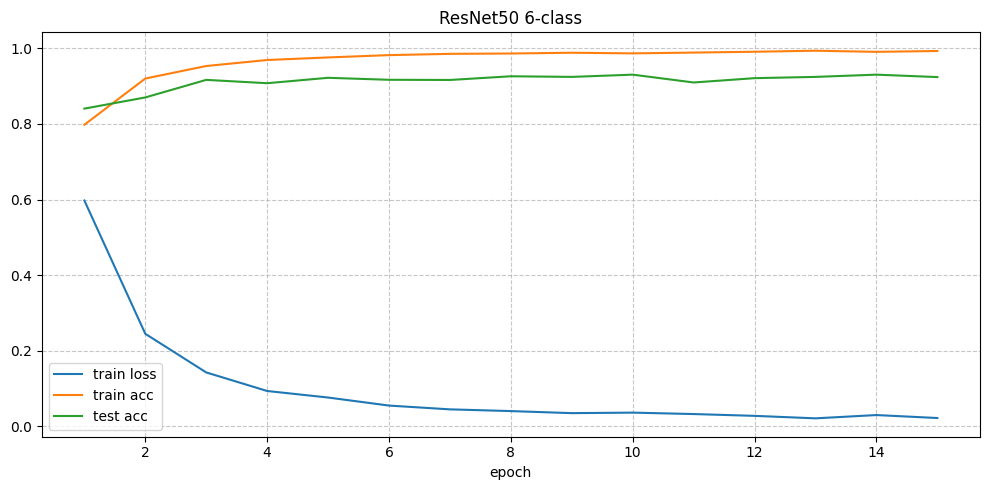

In [28]:
# train_loss
# [0.5974006920227504, 0.24477527916170766, 0.14259084045300505, 0.09348892681802957, 0.07616638575895057, 0.054889986356353775, 0.044880735768180385, 0.040312274307662176, 0.03488141410458363, 0.03623553882541376, 0.03247416968146083, 0.027689423003018788, 0.02111845410749847, 0.029805854058122083, 0.02196057397431961]
# train_acc
# [0.7978316326530612, 0.9200983965014577, 0.9532616618075802, 0.9691144314868805, 0.9759475218658892, 0.982051749271137, 0.9854227405247813, 0.9863338192419825, 0.9883381924198251, 0.986698250728863, 0.9887937317784257, 0.9909803206997084, 0.9937135568513119, 0.9907069970845481, 0.9929846938775511]
# test_acc
# [0.8405244338498212, 0.8700834326579261, 0.9165673420738975, 0.9077473182359952, 0.9220500595947556, 0.9168057210965435, 0.9163289630512514, 0.9261025029797377, 0.9244338498212157, 0.930393325387366, 0.9096543504171632, 0.9210965435041716, 0.9244338498212157, 0.930393325387366, 0.9239570917759237]

epochs = range(1, len(history["train_acc"]) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("epoch")
plt.title("ResNet50 6-class")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet50_6class_curve.png"), dpi=150)
plt.show()